In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
# Get all checkpoint directories
eval_results_dir = Path("/data/ratna/eval_results").expanduser()
ckpt_dirs = sorted([d for d in eval_results_dir.iterdir() if d.is_dir() and d.name.startswith("ckpt_")])
print(len(ckpt_dirs), "checkpoint directories found.")
for d in ckpt_dirs:
    print(d.name)

32 checkpoint directories found.
ckpt_0
ckpt_0_to_250000
ckpt_100000
ckpt_100000_to_300000
ckpt_112500
ckpt_12500
ckpt_125000
ckpt_137500
ckpt_150000
ckpt_162500
ckpt_175000
ckpt_187500
ckpt_187500_to_237500
ckpt_200000
ckpt_212500
ckpt_225000
ckpt_237500
ckpt_25000
ckpt_250000
ckpt_250000_to_325000
ckpt_262500
ckpt_275000
ckpt_287500
ckpt_300000
ckpt_312500
ckpt_325000
ckpt_37500
ckpt_50000
ckpt_62500
ckpt_75000
ckpt_87500
ckpt_87500_to_137500


In [4]:
# Extract step number from checkpoint directory name
def extract_step(dirname):
    # if dirname == "ckpt_87500_to_137500": # removed 0 to 250k average checkpoint - not useful
    #     return "avg_87500_137500" # RSG - make this into a function later 
    # elif dirname == "ckpt_100000_to_300000":
    #     return "avg_100000_300000"
    # elif dirname == "ckpt_187500_to_237500":
    #     return "avg_187500_237500"
    # elif dirname == "ckpt_250000_to_325000":
    #     return "avg_250000_325000"
    # return int(dirname.split("_")[1])

    # Skip averaged checkpoints
    if "to" in dirname:
        if dirname == "ckpt_87500_to_137500":
            return "avg_87500_137500"
        elif dirname == "ckpt_100000_to_300000":
            return "avg_100000_300000"
        elif dirname == "ckpt_187500_to_237500":
            return "avg_187500_237500"
        elif dirname == "ckpt_250000_to_325000":
            return "avg_250000_325000"
        else:
            return None
        
    return int(dirname.split("_")[1])


# Collect all summary.tsv files
all_results = []
for ckpt_dir in ckpt_dirs:
    step = extract_step(ckpt_dir.name)
    if step is None:
        continue
    fast_eval_dirs = list(ckpt_dir.glob("fast_eval_*"))
    
    if not fast_eval_dirs:
        print(f"Warning: No fast_eval directory found in {ckpt_dir.name}")
        continue
    
    # Find the fast_eval subdirectory
    fast_eval_dir = sorted(fast_eval_dirs)[-1]
    summary_file = fast_eval_dir / "summary.tsv"
    
    if not summary_file.exists():
        print(f"Warning: No summary.tsv found in {fast_eval_dir}")
        continue
    
    # Read the summary file
    df = pd.read_csv(summary_file, sep="\t")
    df["step"] = step
    all_results.append(df)
    
    print(f"Loaded {ckpt_dir.name}: {len(df)} datasets")
    
# Combine all results into a single DataFrame
if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)
    print("Combined results shape:", combined_df.shape)
else:
    print("No results found.")

Loaded ckpt_0: 10 datasets
Loaded ckpt_100000: 10 datasets
Loaded ckpt_100000_to_300000: 10 datasets
Loaded ckpt_112500: 10 datasets
Loaded ckpt_12500: 10 datasets
Loaded ckpt_125000: 10 datasets
Loaded ckpt_137500: 10 datasets
Loaded ckpt_150000: 10 datasets
Loaded ckpt_162500: 10 datasets
Loaded ckpt_175000: 10 datasets
Loaded ckpt_187500: 10 datasets
Loaded ckpt_187500_to_237500: 10 datasets
Loaded ckpt_200000: 10 datasets
Loaded ckpt_212500: 10 datasets
Loaded ckpt_225000: 10 datasets
Loaded ckpt_237500: 10 datasets
Loaded ckpt_25000: 10 datasets
Loaded ckpt_250000: 10 datasets
Loaded ckpt_250000_to_325000: 10 datasets
Loaded ckpt_262500: 10 datasets
Loaded ckpt_275000: 10 datasets
Loaded ckpt_287500: 10 datasets
Loaded ckpt_300000: 10 datasets
Loaded ckpt_312500: 10 datasets
Loaded ckpt_325000: 10 datasets
Loaded ckpt_37500: 10 datasets
Loaded ckpt_50000: 10 datasets
Loaded ckpt_62500: 10 datasets
Loaded ckpt_75000: 10 datasets
Loaded ckpt_87500: 10 datasets
Loaded ckpt_87500_to_1

In [5]:
combined_df.head()

,dataset,mode,status,elapsed_sec,metric,metric_mean,runs,start,end,results_json,log_file,step
0,bach,predict_fit,ok,297,val/MulticlassAccuracy,0.648607,"run_1=0.649128, run_2=0.648086",2026-03-02T01:38:37+00:00,2026-03-02T01:43:34+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0
1,bracs,predict_fit,ok,421,test/MulticlassAccuracy,0.538691,"run_1=0.542636, run_2=0.534745",2026-03-02T01:43:35+00:00,2026-03-02T01:50:36+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0
2,breakhist,predict_fit,ok,275,val/MulticlassAccuracy,0.774133,"run_1=0.770730, run_2=0.777537",2026-03-02T01:50:36+00:00,2026-03-02T01:55:11+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0
3,crc,predict_fit,ok,1745,val/MulticlassAccuracy,0.887309,"run_1=0.885296, run_2=0.889322",2026-03-02T01:55:11+00:00,2026-03-02T02:24:16+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0
4,gleason,predict_fit,ok,470,val/MulticlassAccuracy,0.665182,"run_1=0.666442, run_2=0.663922",2026-03-02T02:24:16+00:00,2026-03-02T02:32:06+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0


In [6]:
# Check what columns we have
print("Available columns:")
print(combined_df.columns.tolist())
print("\nDatasets:")
print(combined_df['dataset'].unique())
print("\nMetrics:")
print(combined_df['metric'].unique())

Available columns:
['dataset', 'mode', 'status', 'elapsed_sec', 'metric', 'metric_mean', 'runs', 'start', 'end', 'results_json', 'log_file', 'step']

Datasets:
['bach' 'bracs' 'breakhist' 'crc' 'gleason' 'mhist' 'pcam_10' 'pcam'
 'consep' 'monusac']

Metrics:
['val/MulticlassAccuracy' 'test/MulticlassAccuracy'
 'val/BinaryBalancedAccuracy' 'test/BinaryBalancedAccuracy'
 'val/MonaiDiceScore']


In [7]:
# Average metrics across all datasets for each step
numeric_steps = []
averaged_checkpoints = {}

for step in combined_df["step"].unique():
    if isinstance(step, str) and 'avg' in step:
        averaged_checkpoints[step] = combined_df[combined_df['step'] == step].copy()
    else:
        numeric_steps.append(step)
        
numeric_steps.sort()

aggregated_results = []
# Process individual checkpoints
for step in numeric_steps:
    step_data = combined_df[combined_df["step"] == step]
    mean_value = step_data["metric_mean"].mean()
    aggregated_results.append({
        "step": step,
        "mean_metric": mean_value,
        "num_datasets": len(step_data),
        "type": "individual"
    })
    
# Add all averaged checkpoints
for avg_name, avg_data in averaged_checkpoints.items():
    mean_value = avg_data["metric_mean"].mean()
    aggregated_results.append({
        'step': avg_name,
        'mean_metric': mean_value,
        'num_datasets': len(avg_data),
        'type': 'averaged'
    })
    
agg_df = pd.DataFrame(aggregated_results)
agg_df

,step,mean_metric,num_datasets,type
0,0,0.686049,10,individual
1,12500,0.772774,10,individual
2,25000,0.786418,10,individual
3,37500,0.788173,10,individual
4,50000,0.798483,10,individual
5,62500,0.800722,10,individual
6,75000,0.804525,10,individual
7,87500,0.801898,10,individual
8,100000,0.809284,10,individual
9,112500,0.807279,10,individual


In [8]:
agg_df.sort_values(by="mean_metric", ascending=False)[:5]

,step,mean_metric,num_datasets,type
30,avg_87500_137500,0.812430,10,averaged
23,287500,0.810710,10,individual
27,avg_100000_300000,0.810495,10,averaged
24,300000,0.809570,10,individual
8,100000,0.809284,10,individual


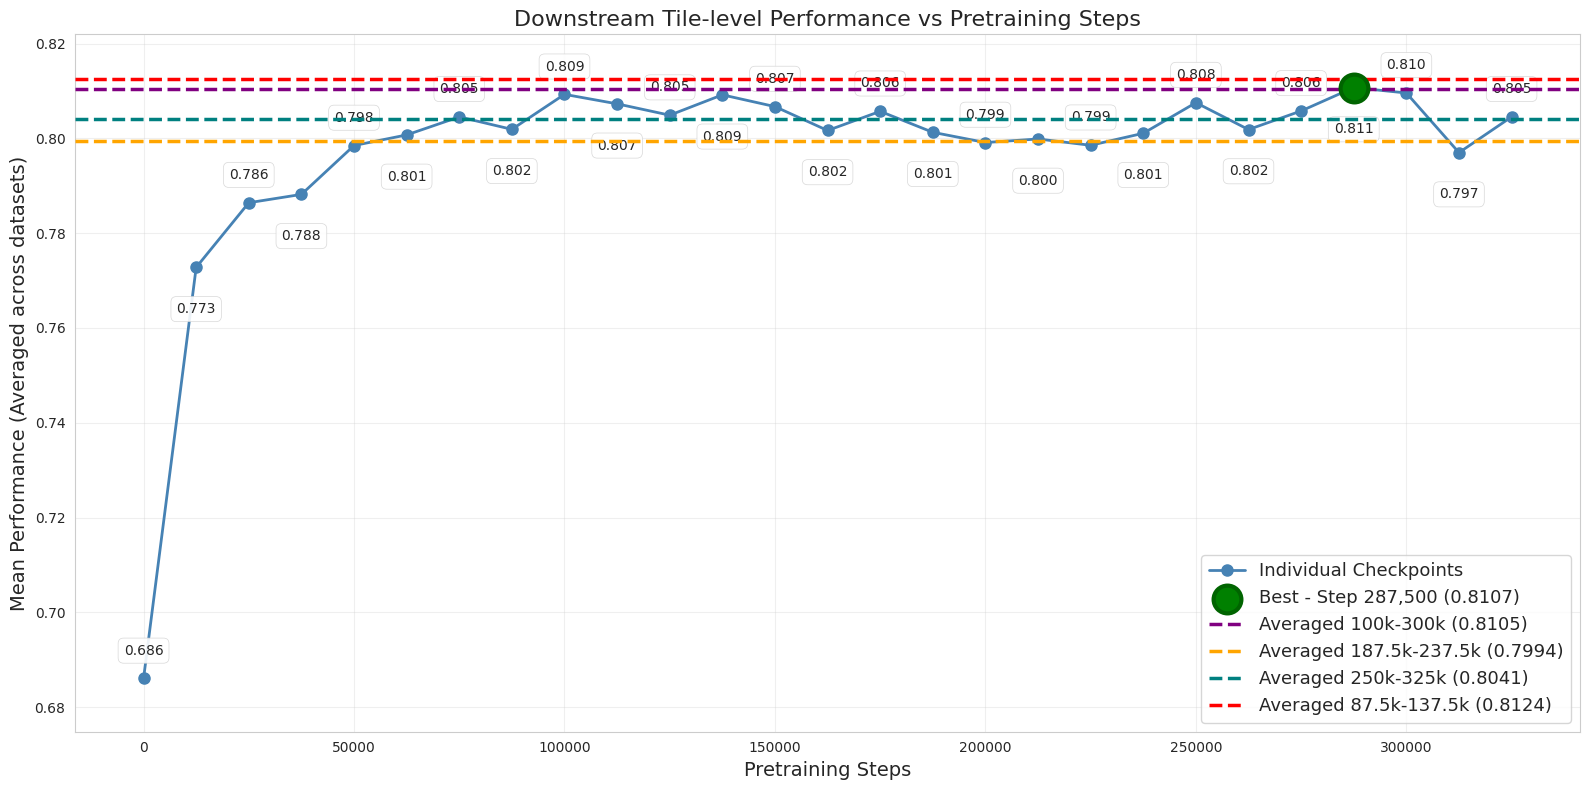

Plot saved as 'pretraining_performance_all_avgs.png'
Best checkpoint: Step 287,500 with mean metric 0.8107

Averaged checkpoints:
  100k-300k: 0.8105
  187.5k-237.5k: 0.7994
  250k-325k: 0.8041
  87.5k-137.5k: 0.8124


In [9]:
# Plot 1: Mean performance vs pretraining steps
fig, ax = plt.subplots(figsize=(16, 8))

# Plot individual checkpoints
individual_data = agg_df[agg_df['type'] == 'individual'].copy()
individual_data = individual_data.sort_values('step')

# Find the best checkpoint (highest mean_metric)
best_idx = individual_data['mean_metric'].idxmax()
best_step = individual_data.loc[best_idx, 'step']
best_value = individual_data.loc[best_idx, 'mean_metric']

# Plot all checkpoints
ax.plot(individual_data['step'], individual_data['mean_metric'], 
        marker='o', linewidth=2, markersize=8, label='Individual Checkpoints', 
        color='steelblue')

# Add value labels on each point with alternating positions
for i, (idx, row) in enumerate(individual_data.iterrows()):
    # Alternate between above and below to reduce crowding
    y_offset = 15 if i % 2 == 0 else -25
    va = 'bottom' if i % 2 == 0 else 'top'
    
    ax.annotate(f'{row["mean_metric"]:.3f}', 
                xy=(row['step'], row['mean_metric']),
                xytext=(0, y_offset),  # Alternating offset
                textcoords='offset points',
                ha='center',
                va=va,
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='lightgray', alpha=0.9, linewidth=0.5))

# Highlight the best checkpoint in green
ax.scatter([best_step], [best_value], 
          color='green', marker='o', s=400, zorder=5, 
          label=f'Best - Step {best_step:,} ({best_value:.4f})', 
          edgecolors='darkgreen', linewidths=3)

# Add averaged checkpoint as horizontal dotted line if it exists
averaged_data = agg_df[agg_df['type'] == 'averaged']
if len(averaged_data) > 0:
    colors = ['purple', 'orange', 'teal', 'red']  # Add more colors if you have more averaged checkpoints
    linestyles = ['--', '--', '--', '--']
    # Define display names for averaged checkpoints
    display_names = {
        'avg_87500_137500': '87.5k-137.5k',
        'avg_100000_300000': '100k-300k',
        'avg_187500_237500': '187.5k-237.5k',
        'avg_250000_325000': '250k-325k'
    }
    
    for i, (idx, row) in enumerate(averaged_data.iterrows()):
        step_name = row["step"]
        display_name = display_names.get(step_name, step_name)
        ax.axhline(y=row["mean_metric"], 
                   color=colors[i%len(colors)], 
                   linestyle=linestyles[i%len(linestyles)], 
                   linewidth=2.5, 
               label=f'Averaged {display_name} ({row["mean_metric"]:.4f})', 
               zorder=4)

ax.set_xlabel('Pretraining Steps', fontsize=14)
ax.set_ylabel('Mean Performance (Averaged across datasets)', fontsize=14)
ax.set_title('Downstream Tile-level Performance vs Pretraining Steps', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=13, loc='best')

# Add some margin to y-axis to accommodate labels
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - 0.005, y_max + 0.005)

# Format x-axis
ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('pretraining_performance_all_avgs.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved as 'pretraining_performance_all_avgs.png'")
print(f"Best checkpoint: Step {best_step:,} with mean metric {best_value:.4f}")

# Print all averaged checkpoint performances
print("\nAveraged checkpoints:")
for idx, row in averaged_data.iterrows():
    display_name = display_names.get(row['step'], row['step'])
    print(f"  {display_name}: {row['mean_metric']:.4f}")

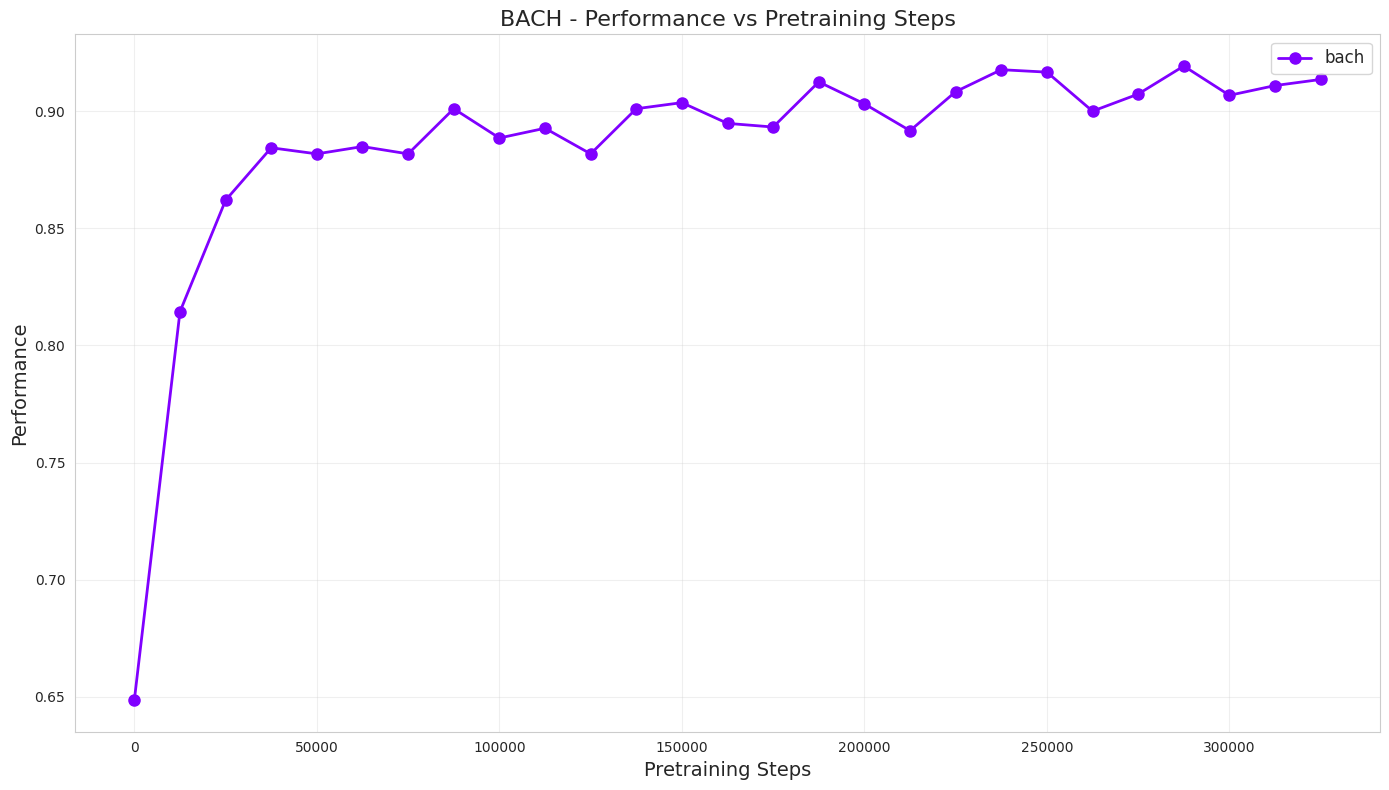

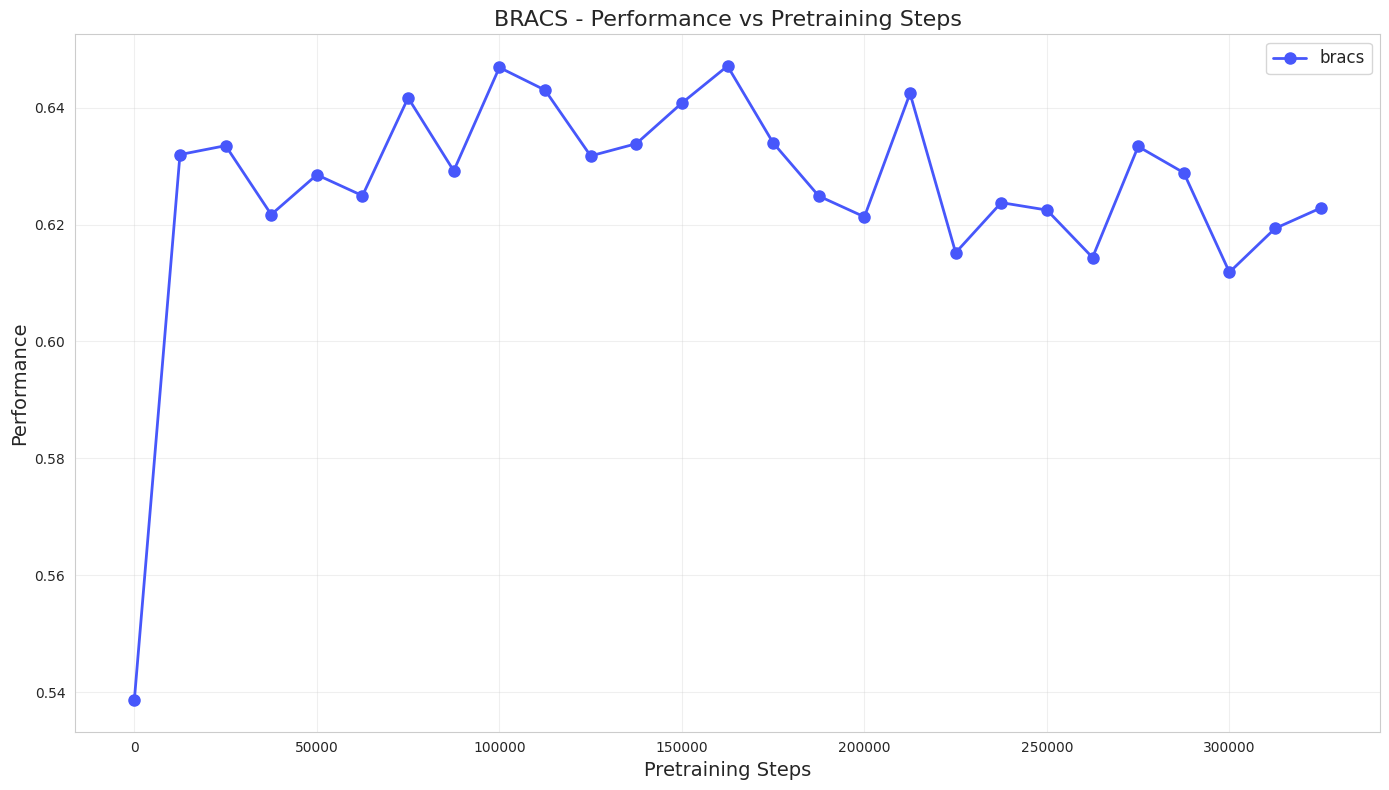

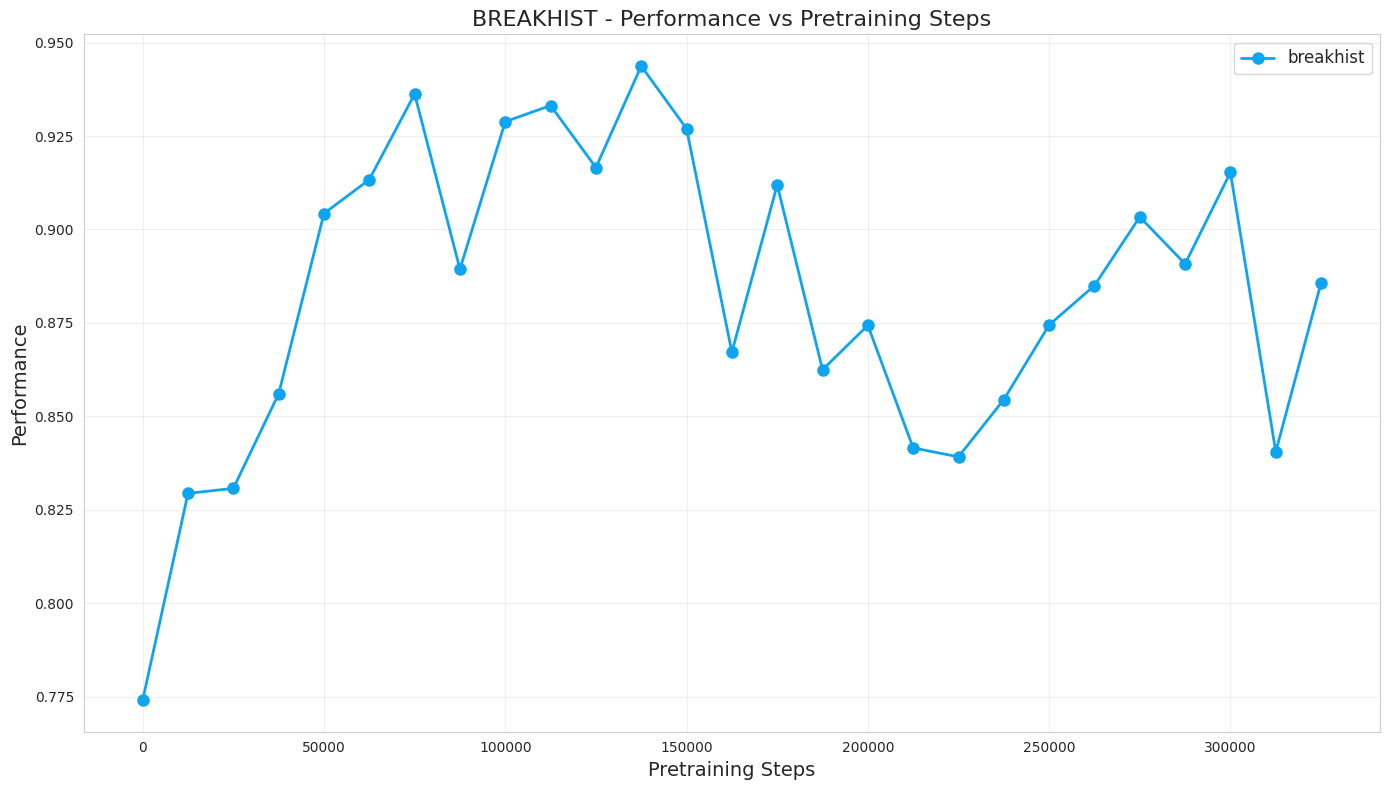

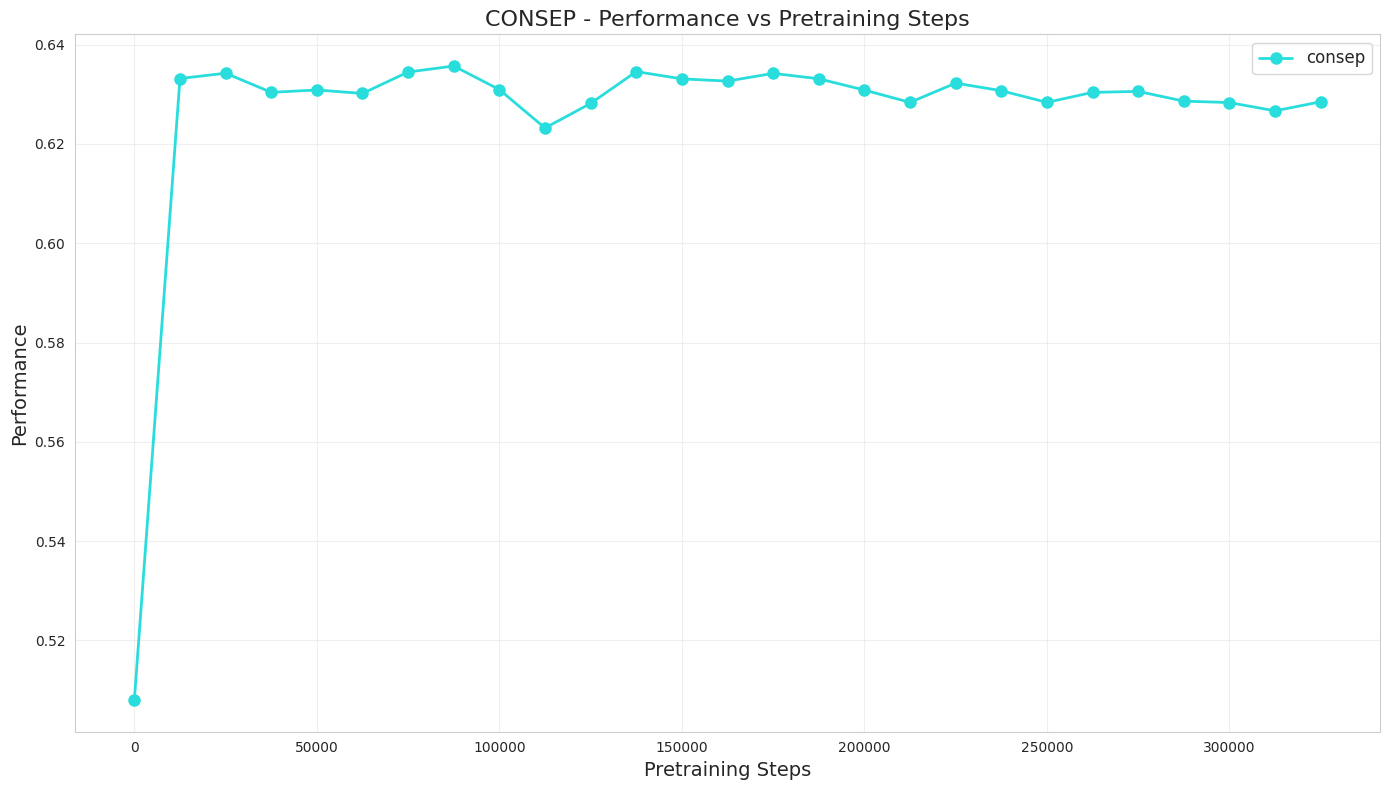

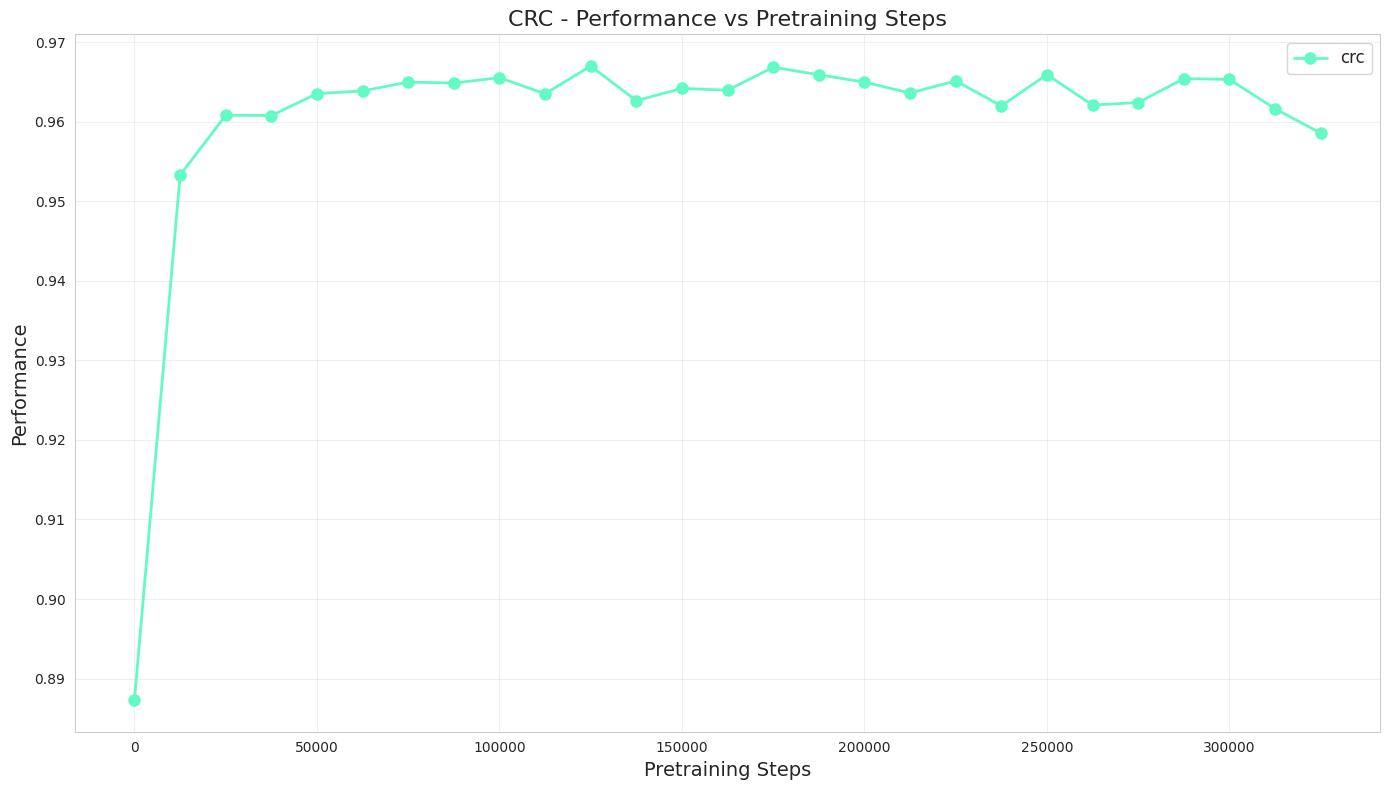

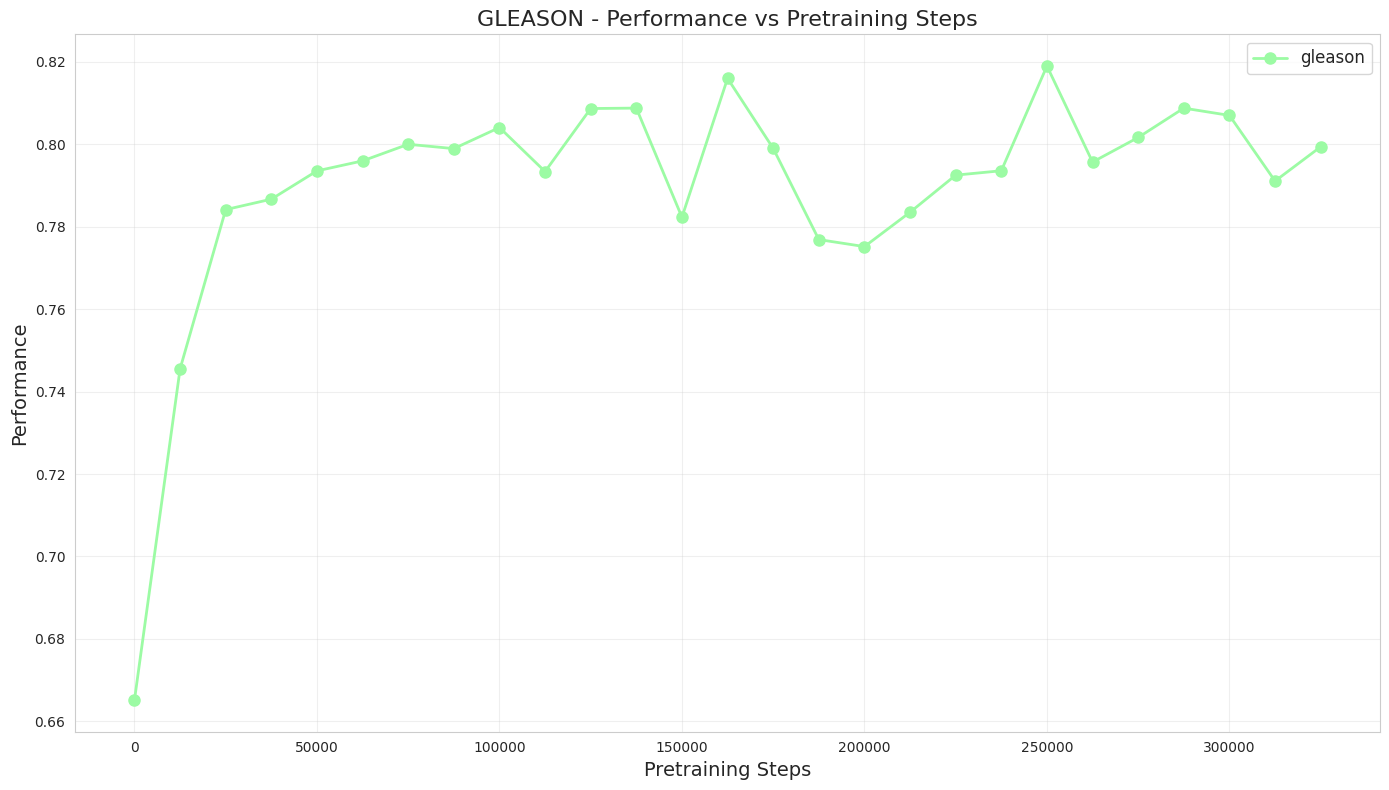

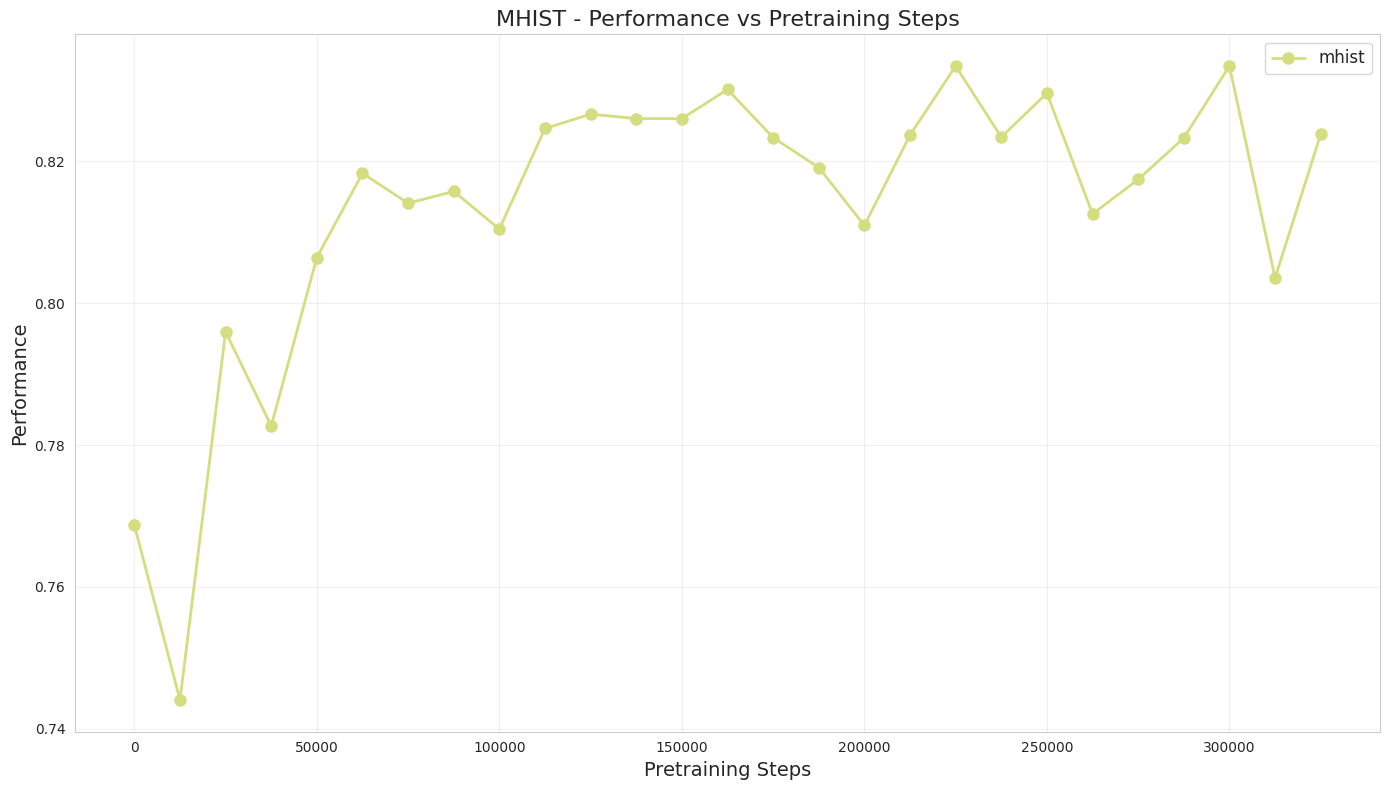

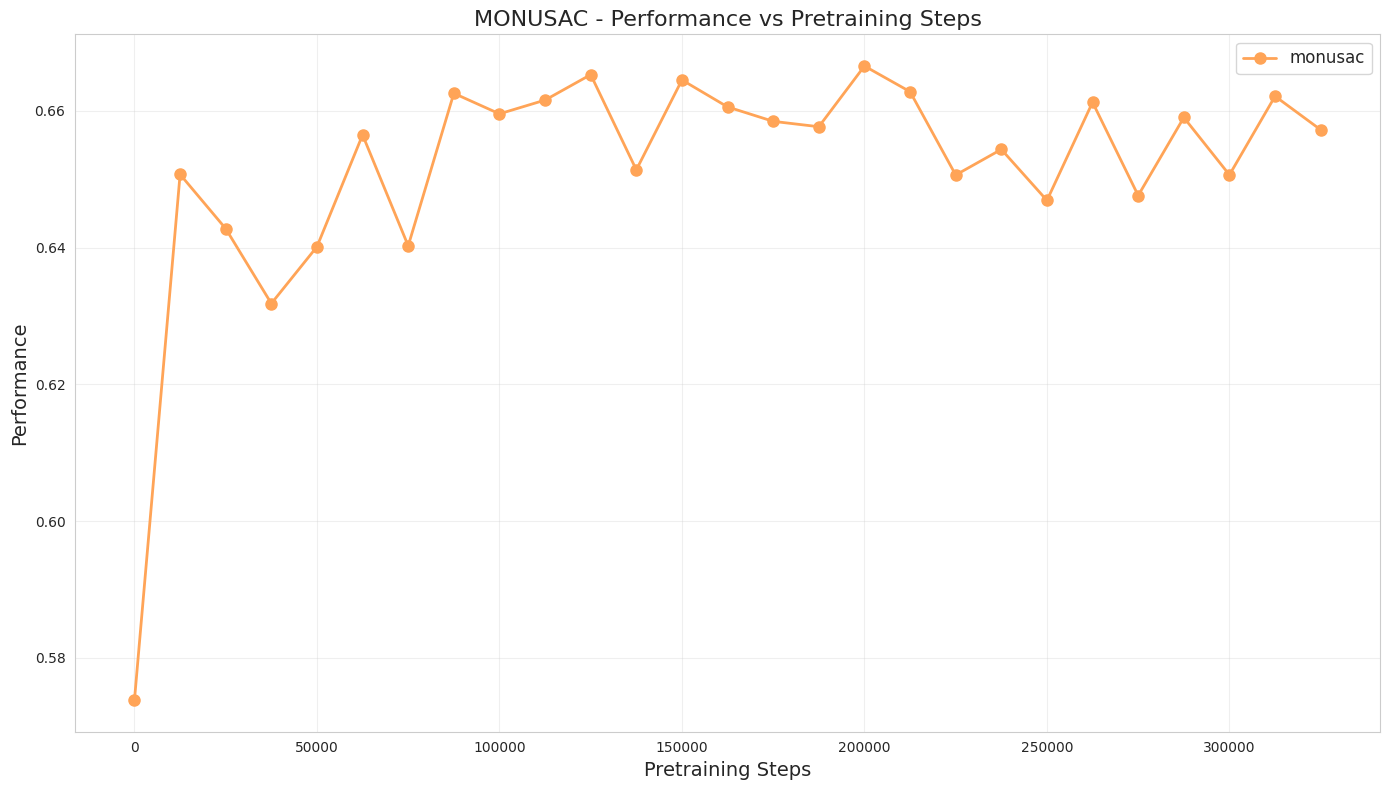

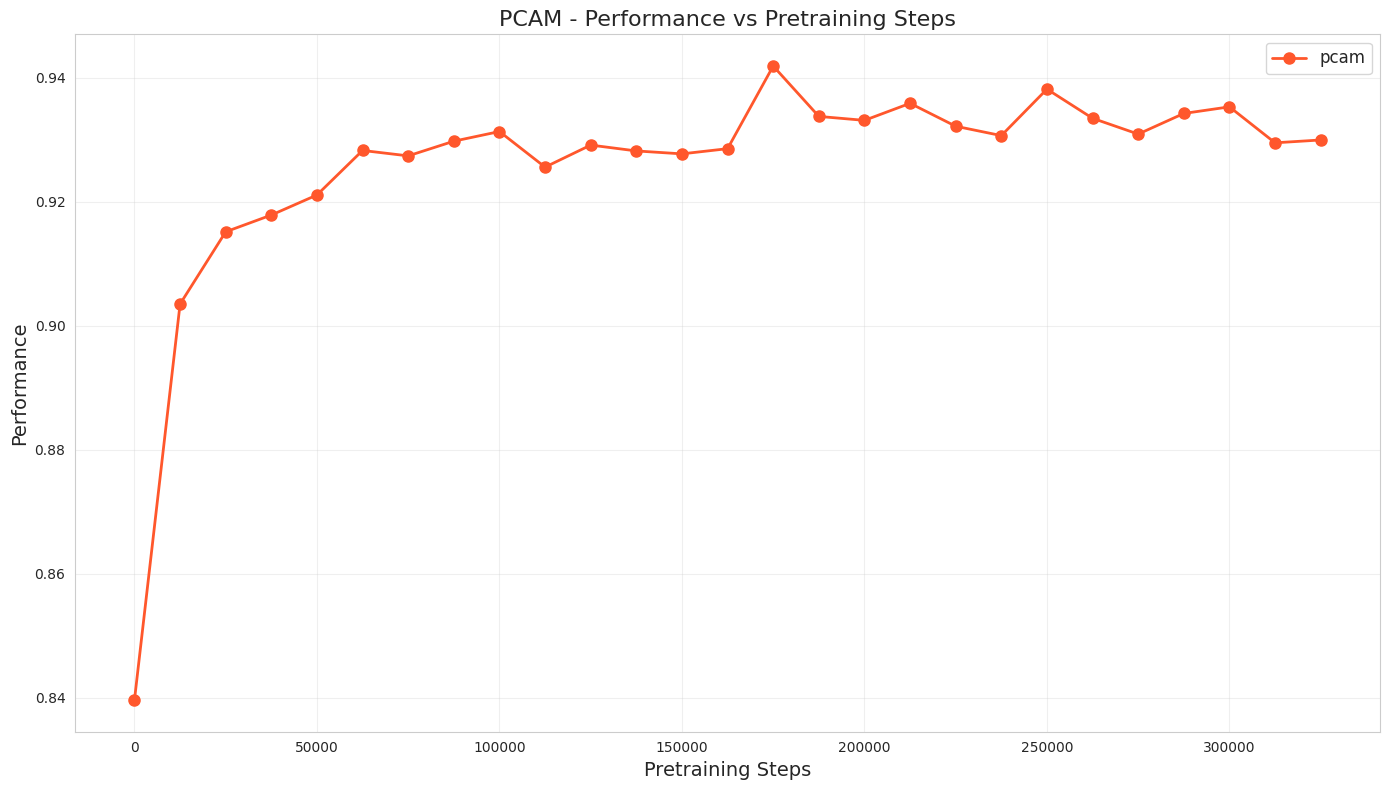

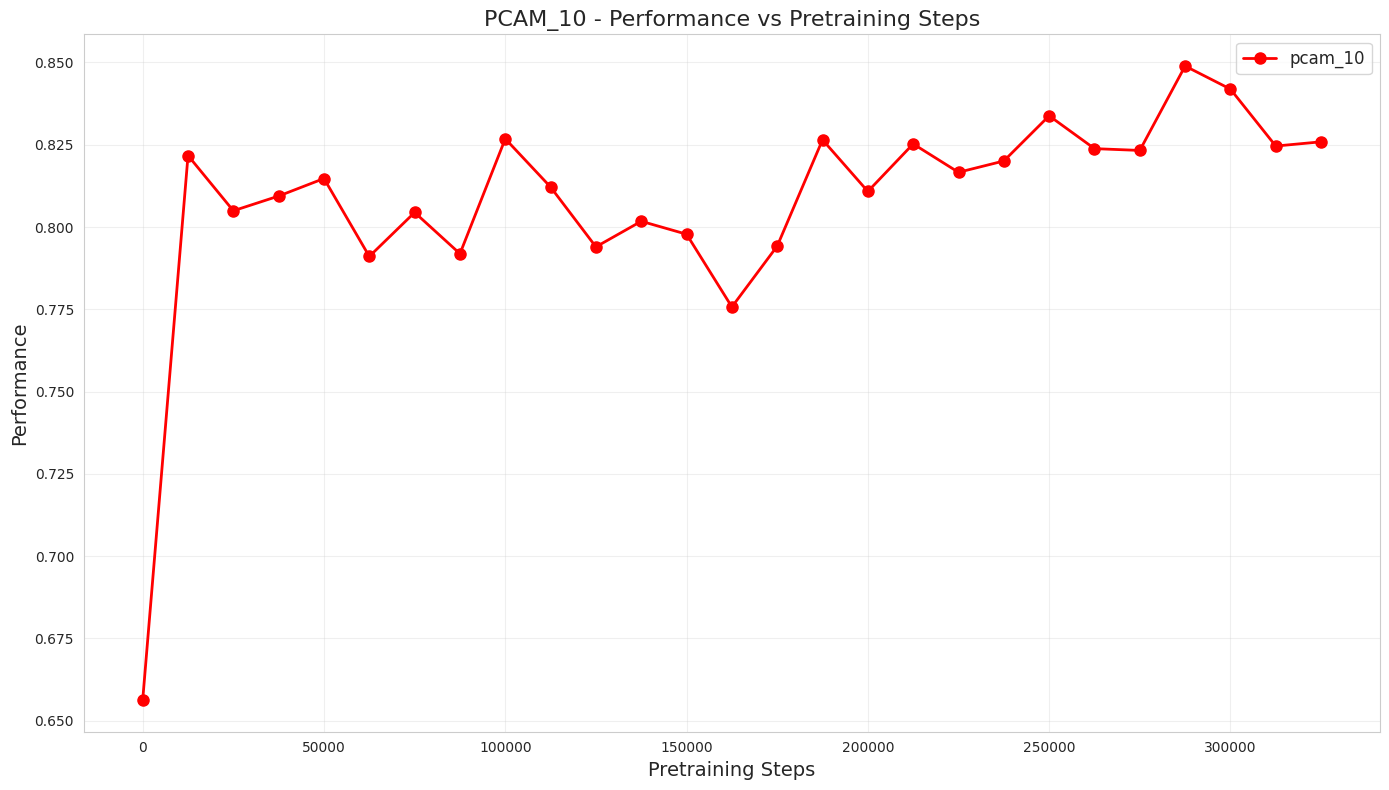

Saved 10 individual dataset plots


In [12]:
# Plot 2: Per-dataset performance vs pretraining steps - Individual plots
individual_df = combined_df[~combined_df["step"].astype(str).str.contains('avg')].copy()
individual_df = individual_df.dropna(subset=['metric_mean'])
individual_df["step"] = individual_df["step"].astype(int)  # Convert to int FIRST
# individual_df = individual_df[individual_df["step"] <= 137500]
individual_df = individual_df.sort_values('step')  # Then sort numerically
individual_df = individual_df.drop_duplicates(subset=["dataset", "step"])  # Remove any duplicates

colors = plt.get_cmap('rainbow', 10)

for i, (dataset, group) in enumerate(individual_df.groupby("dataset")):
    group = group.sort_values("step")
    fig, ax = plt.subplots(figsize=(14, 8))
    
    ax.plot(group["step"], group["metric_mean"], marker='o', linewidth=2, 
            markersize=8, label=dataset, color=colors(i))
    
    ax.set_xlabel('Pretraining Steps', fontsize=14)
    ax.set_ylabel('Performance', fontsize=14)
    ax.set_title(f'{dataset.upper()} - Performance vs Pretraining Steps', 
                 fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'per_dataset_{dataset}.png', dpi=300, bbox_inches='tight')
    plt.show() 

print("Saved 10 individual dataset plots")

In [13]:
# After filtering to 137.5K
consep_data = individual_df[individual_df['dataset'] == 'consep']
print(f"CoNSeP data points: {len(consep_data)}")
print(f"CoNSeP steps: {sorted(consep_data['step'].unique())}")
print(f"CoNSeP configs: {consep_data.value_counts()}")

print(consep_data[['step', 'metric_mean']].sort_values('step'))

CoNSeP data points: 27
CoNSeP steps: [np.int64(0), np.int64(12500), np.int64(25000), np.int64(37500), np.int64(50000), np.int64(62500), np.int64(75000), np.int64(87500), np.int64(100000), np.int64(112500), np.int64(125000), np.int64(137500), np.int64(150000), np.int64(162500), np.int64(175000), np.int64(187500), np.int64(200000), np.int64(212500), np.int64(225000), np.int64(237500), np.int64(250000), np.int64(262500), np.int64(275000), np.int64(287500), np.int64(300000), np.int64(312500), np.int64(325000)]
CoNSeP configs: dataset  mode  status  elapsed_sec  metric              metric_mean  runs                            start                      end                        results_json                                                                                                                                  log_file                                                                                           step  
consep   fit   ok      5305         val/MonaiDiceScore  0.630157     

The End